In [22]:
import numpy as np 
import pandas as pd



In [23]:
spam = pd.read_csv("spam1.csv",encoding="ISO-8859-1")
spam.head()
spam.shape


(5572, 5)

## Data cleaning

In [24]:
## Data cleaning
spam.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [25]:
spam.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)


In [26]:
spam.head()
spam.rename(columns={"v1": "label", "v2": "text"}, inplace=True)

In [27]:
spam.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [28]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
spam['label'] = encoder.fit_transform(spam['label'])

# converts ham to 0 and spam to 1


In [29]:
spam.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [30]:
spam.isnull().sum()

label    0
text     0
dtype: int64

In [31]:
spam.duplicated().sum()

np.int64(403)

In [32]:
spam = spam.drop_duplicates(keep='first')

In [33]:
spam.shape

(5169, 2)

## EDA

In [35]:
spam['label'].value_counts()


label
0    4516
1     653
Name: count, dtype: int64

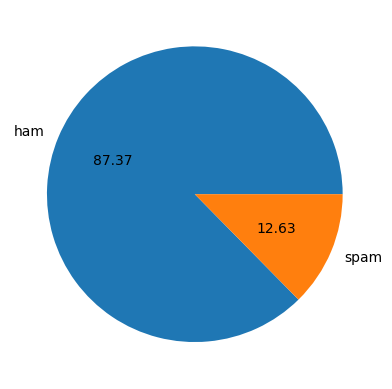

In [38]:
import matplotlib.pyplot as plt
plt.pie(spam['label'].value_counts(),labels = ['ham','spam'],autopct = '%0.2f')
plt.show()

In [39]:
## now in every sms let calculate words sentences characters this is nice eda 

spam['characters'] = spam['text'].apply(len)

In [40]:
spam.head()

,label,text,characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [41]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')



[nltk_data] Downloading package punkt to
[nltk_data]     /Users/darshgupta/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [42]:
def count_words(text):
    tokens = word_tokenize(text)
    return len(tokens)



In [43]:
spam['words'] = spam['text'].apply(count_words)
spam.head()

,label,text,characters,words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [45]:
from nltk.tokenize import sent_tokenize
def count_sentences(text):
    return len(sent_tokenize(text))


In [46]:
spam['sentences'] = spam['text'].apply(count_sentences)
spam.head()

,label,text,characters,words,sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [47]:
spam[spam['label']==0][['characters','words','sentences']].describe()


,characters,words,sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [48]:
spam[spam['label']==1][['characters','words','sentences']].describe()


,characters,words,sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [50]:
import seaborn as sns

<Axes: xlabel='characters', ylabel='Count'>

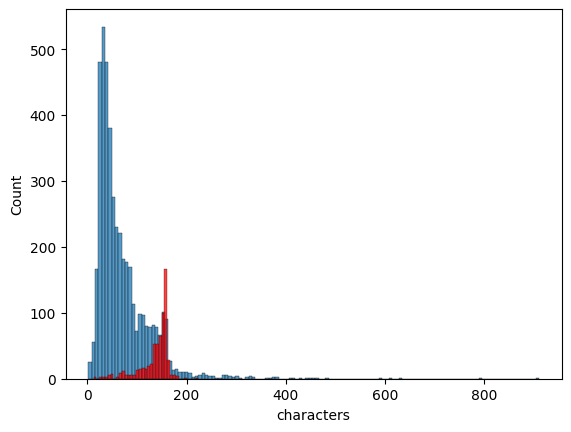

In [57]:
sns.histplot(spam[spam['label']==0]['characters'])
sns.histplot(spam[spam['label']==1]['characters'],color='red')

## by this we see spam takes more charcters then ham nice ead

<Axes: xlabel='words', ylabel='Count'>

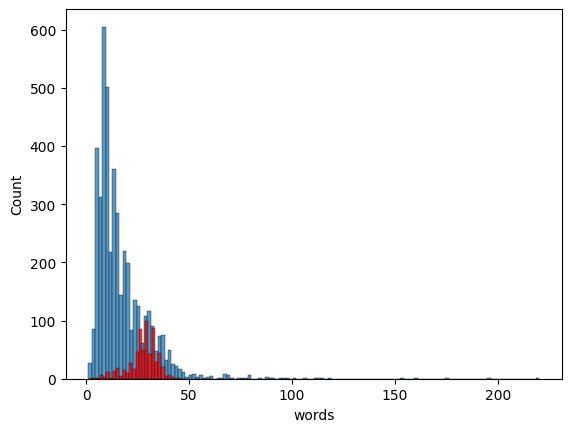

In [56]:
sns.histplot(spam[spam['label']==0]['words'])
sns.histplot(spam[spam['label']==1]['words'],color='red')

## Preprocessing

In [59]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/darshgupta/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/darshgupta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/darshgupta/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [60]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()


In [61]:
def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)

    # remove punctuation & numbers
    tokens = [w for w in tokens if w.isalnum()]

    # remove stopwords
    tokens = [w for w in tokens if w not in stop_words]

    # lemmatize then stem
    tokens = [stemmer.stem(lemmatizer.lemmatize(w)) for w in tokens]

    return " ".join(tokens)


In [62]:
spam['clean_text'] = spam['text'].apply(preprocess_text)


In [63]:
spam.head()

,label,text,characters,words,sentences,clean_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf life around though


In [64]:
ham_text = spam[spam['label'] == 0]['clean_text']
spam_text = spam[spam['label'] == 1]['clean_text']


In [65]:
from collections import Counter

ham_words = Counter(" ".join(ham_text).split())
spam_words = Counter(" ".join(spam_text).split())

ham_top30 = ham_words.most_common(30)
spam_top30 = spam_words.most_common(30)


In [66]:
import pandas as pd

ham_df = pd.DataFrame(ham_top30, columns=['word', 'count'])
spam_df = pd.DataFrame(spam_top30, columns=['word', 'count'])


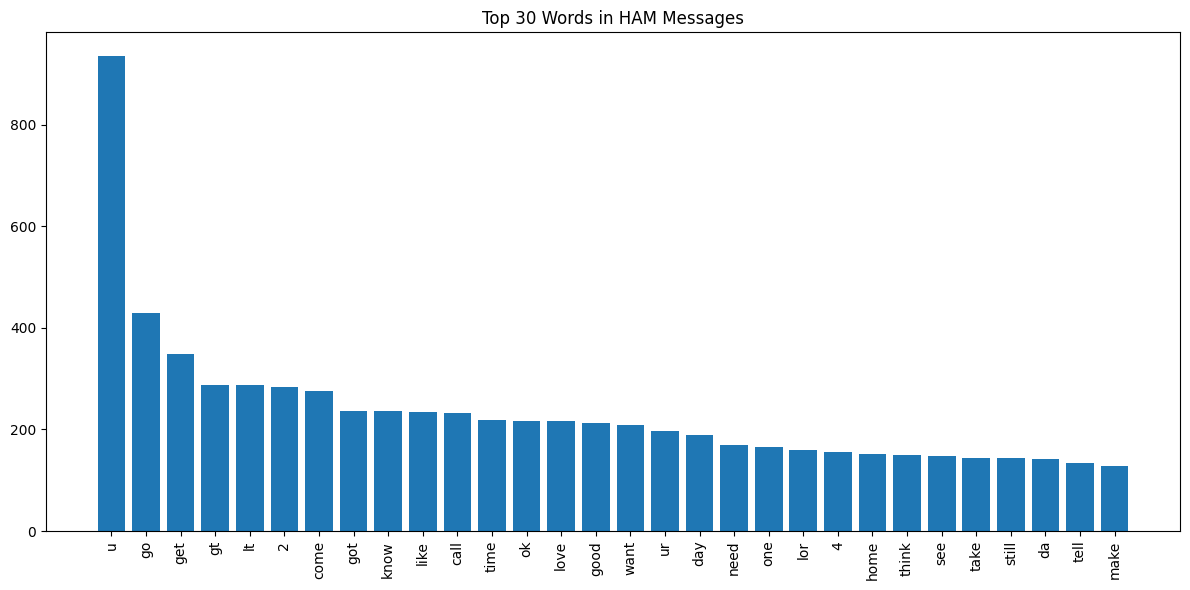

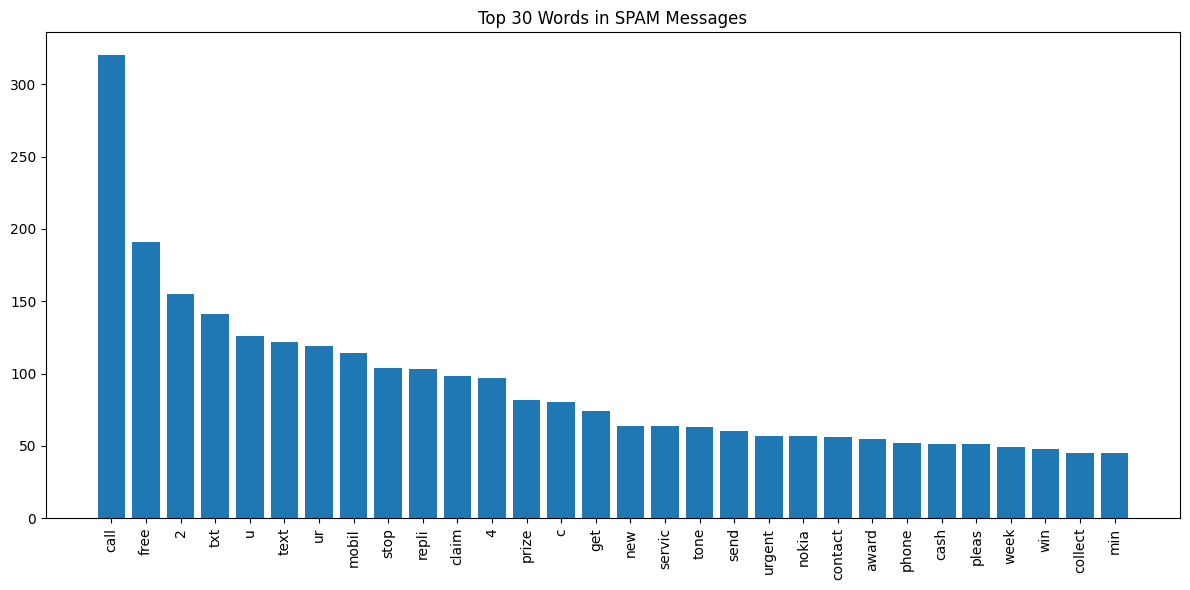

In [67]:
import matplotlib.pyplot as plt

# Ham words
plt.figure(figsize=(12,6))
plt.bar(ham_df['word'], ham_df['count'])
plt.xticks(rotation=90)
plt.title("Top 30 Words in HAM Messages")
plt.tight_layout()
plt.show()

# Spam words
plt.figure(figsize=(12,6))
plt.bar(spam_df['word'], spam_df['count'])
plt.xticks(rotation=90)
plt.title("Top 30 Words in SPAM Messages")
plt.tight_layout()
plt.show()


## Model building

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(spam['clean_text']).toarray()
y = spam['label']


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [70]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9706109822119103
Precision: 0.9868421052631579
Recall: 0.8064516129032258
Confusion Matrix:
 [[1105    2]
 [  36  150]]


In [73]:
def predict_spam(text):
    text = preprocess_text(text)
    vec = tfidf.transform([text])
    return "Spam" if model.predict(vec)[0] == 1 else "Not Spam"

predict_spam("hi darsh lets go out")


'Not Spam'